# 5-Bar Oscillating Linkage - Kinematic Analysis

Plots for the position, velocity, and acceleration of points A and B of the 5-bar oscillating linkage mechanism (reference configuration: r1=280, r2=140, r3=240, r4=190, r5=150, alpha=0.6 rad).

## Part 1: Trajectories of points A and B

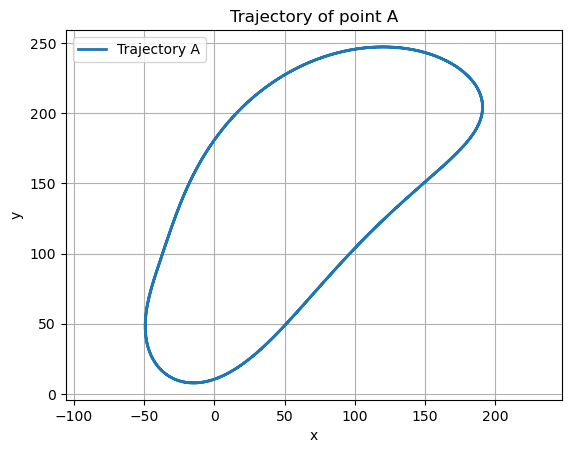

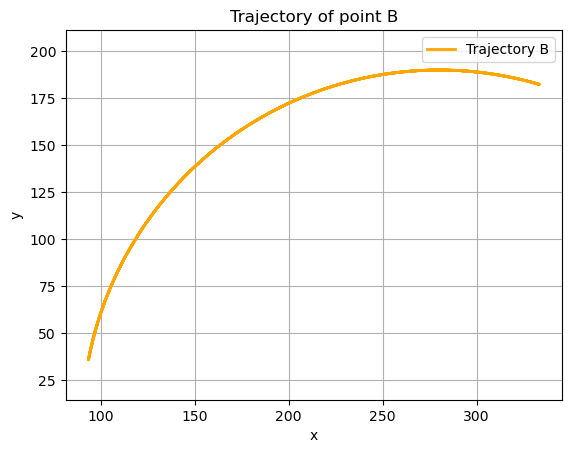

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# load position data (produced by part1_position_analysis.cpp / part2_velocity_acceleration.cpp)
trajectory_A = pd.read_csv("data/trajectory_A.csv")
trajectory_B = pd.read_csv("data/trajectory_B.csv")

# plot trajectory of A
plt.figure()
plt.plot(trajectory_A["xA"], trajectory_A["yA"], label="Trajectory A", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectory of point A")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.savefig("data/trajectory_A.png", dpi=150, bbox_inches="tight")
plt.show()

# plot trajectory of B
plt.figure()
plt.plot(trajectory_B["xB"], trajectory_B["yB"], label="Trajectory B", color="orange", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectory of point B")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.savefig("data/trajectory_B.png", dpi=150, bbox_inches="tight")
plt.show()


## Part 2: Position, velocity, and acceleration vs. time

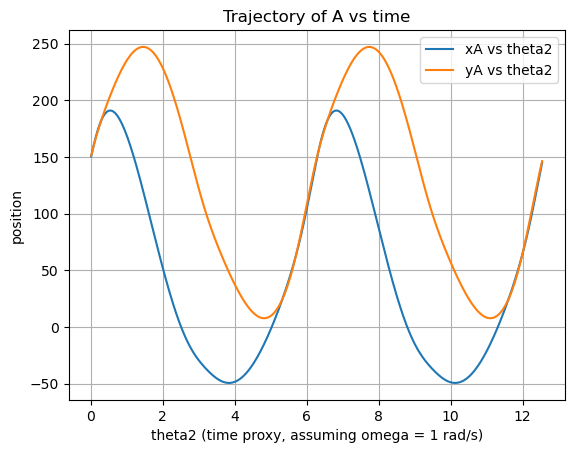

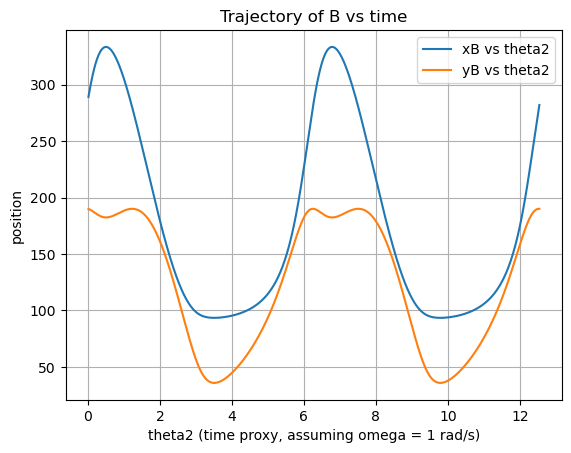

In [2]:
import matplotlib.pyplot as plt
import csv

def read_csv_two_columns(filename):
    x, y = [], []
    with open(filename, 'r') as f:
        next(f)
        for row in csv.reader(f):
            if len(row) >= 2:
                x.append(float(row[0]))
                y.append(float(row[1]))
    return x, y

def read_csv_three_columns(filename):
    t, x, y = [], [], []
    with open(filename, 'r') as f:
        next(f)
        for row in csv.reader(f):
            if len(row) >= 3:
                t.append(float(row[0]))
                x.append(float(row[1]))
                y.append(float(row[2]))
    return t, x, y

# read positions
xA, yA = read_csv_two_columns("data/trajectory_A.csv")
xB, yB = read_csv_two_columns("data/trajectory_B.csv")

# use the time proxy (theta2) from velocity_A.csv -- the finite-difference
# arrays are one sample shorter on each side than the raw trajectory arrays
t_vals, _, _ = read_csv_three_columns("data/velocity_A.csv")

# align array lengths
n = min(len(t_vals), len(xA) - 2)  # because we use xA[1:-1]
t_vals = t_vals[:n]
xA = xA[1:n + 1]
yA = yA[1:n + 1]
xB = xB[1:n + 1]
yB = yB[1:n + 1]

# NOTE: theta2 is used here as a time proxy, which is only valid because the
# simulation assumes constant angular velocity omega = 1 rad/s (see
# part2_velocity_acceleration.cpp), so t = theta2 / omega = theta2.

# trajectory A vs time
plt.figure()
plt.plot(t_vals, xA, label="xA vs theta2")
plt.plot(t_vals, yA, label="yA vs theta2")
plt.xlabel("theta2 (time proxy, assuming omega = 1 rad/s)")
plt.ylabel("position")
plt.title("Trajectory of A vs time")
plt.grid()
plt.legend()

# trajectory B vs time
plt.figure()
plt.plot(t_vals, xB, label="xB vs theta2")
plt.plot(t_vals, yB, label="yB vs theta2")
plt.xlabel("theta2 (time proxy, assuming omega = 1 rad/s)")
plt.ylabel("position")
plt.title("Trajectory of B vs time")
plt.grid()
plt.legend()

plt.show()


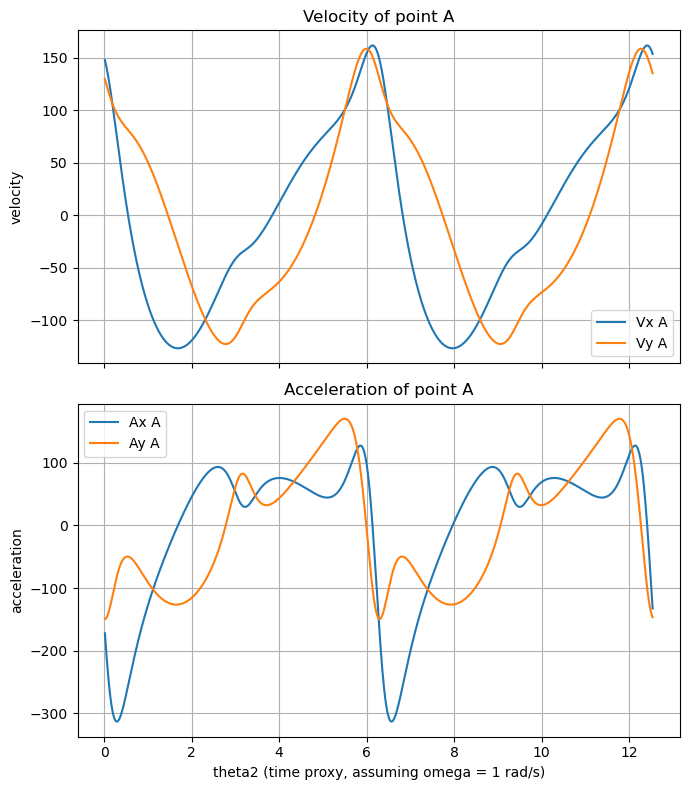

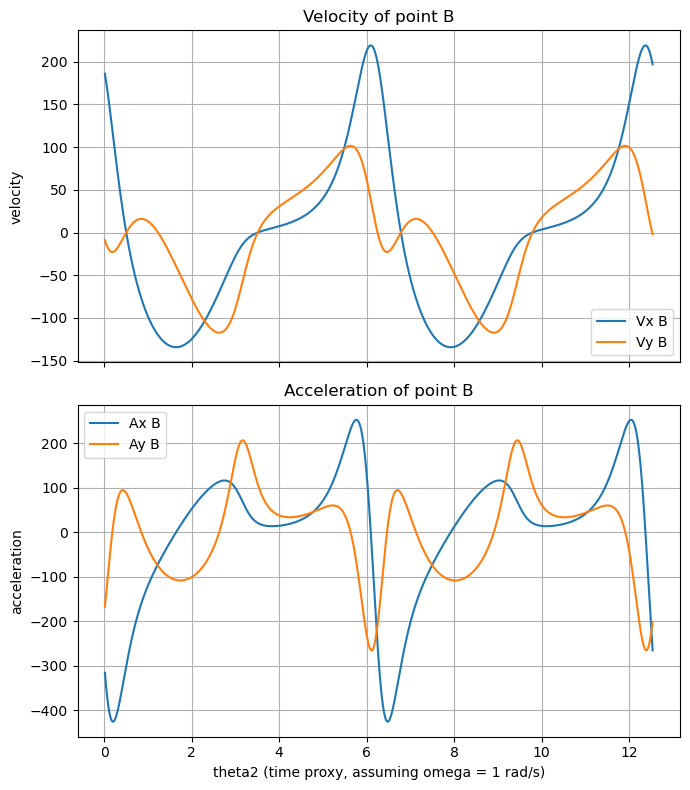

Vx A range: -126.539476 161.466708
Vy A range: -122.504809 158.351728
Ax A range: -313.317664 127.652001
Ay A range: -149.383606 170.440877


In [3]:
import matplotlib.pyplot as plt
import csv

def read_csv_two_columns(filename):
    x, y = [], []
    with open(filename, 'r') as f:
        next(f)
        for row in csv.reader(f):
            if len(row) >= 2:
                x.append(float(row[0]))
                y.append(float(row[1]))
    return x, y

def read_csv_three_columns(filename):
    t, val1, val2 = [], [], []
    with open(filename, 'r') as f:
        next(f)
        for row in csv.reader(f):
            if len(row) >= 3:
                t.append(float(row[0]))
                val1.append(float(row[1]))
                val2.append(float(row[2]))
    return t, val1, val2


# velocity A
tA, vxA, vyA = read_csv_three_columns("data/velocity_A.csv")
# acceleration A
tAccA, axA, ayA = read_csv_three_columns("data/acceleration_A.csv")

# combined velocity + acceleration figure for point A
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
axes[0].plot(tA, vxA, label="Vx A")
axes[0].plot(tA, vyA, label="Vy A")
axes[0].set_ylabel("velocity")
axes[0].set_title("Velocity of point A")
axes[0].grid()
axes[0].legend()

axes[1].plot(tAccA, axA, label="Ax A")
axes[1].plot(tAccA, ayA, label="Ay A")
axes[1].set_xlabel("theta2 (time proxy, assuming omega = 1 rad/s)")
axes[1].set_ylabel("acceleration")
axes[1].set_title("Acceleration of point A")
axes[1].grid()
axes[1].legend()

fig.tight_layout()
fig.savefig("data/velocity_acceleration_A.png", dpi=150, bbox_inches="tight")
plt.show()

# velocity B
tB, vxB, vyB = read_csv_three_columns("data/velocity_B.csv")
# acceleration B
tAccB, axB, ayB = read_csv_three_columns("data/acceleration_B.csv")

# combined velocity + acceleration figure for point B
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
axes[0].plot(tB, vxB, label="Vx B")
axes[0].plot(tB, vyB, label="Vy B")
axes[0].set_ylabel("velocity")
axes[0].set_title("Velocity of point B")
axes[0].grid()
axes[0].legend()

axes[1].plot(tAccB, axB, label="Ax B")
axes[1].plot(tAccB, ayB, label="Ay B")
axes[1].set_xlabel("theta2 (time proxy, assuming omega = 1 rad/s)")
axes[1].set_ylabel("acceleration")
axes[1].set_title("Acceleration of point B")
axes[1].grid()
axes[1].legend()

fig.tight_layout()
fig.savefig("data/velocity_acceleration_B.png", dpi=150, bbox_inches="tight")
plt.show()

print("Vx A range:", min(vxA), max(vxA))
print("Vy A range:", min(vyA), max(vyA))
print("Ax A range:", min(axA), max(axA))
print("Ay A range:", min(ayA), max(ayA))


## Part 3: Area enclosed by the trajectory of point A

Computed with the shoelace formula in `part3_trajectory_area.cpp` (one period of theta2, [0, 2*pi]).

In [4]:
import pandas as pd

area_df = pd.read_csv("data/enclosed_area.csv", header=None, names=["quantity", "value"])
area_value = area_df.loc[area_df["quantity"] == "area_sq_units", "value"].iloc[0]
print(f"Area enclosed by the trajectory of point A: {area_value:.2f} square units")


Area enclosed by the trajectory of point A: 31253.42 square units
